In [ ]:
# ==========================================
# ETL + LIMPEZA + GRÁFICOS + EXPORTAÇÃO PARA LOOKER STUDIO
# Rode esse script célula por célula no Google Colab.
# ==========================================

# --- CÉLULA 1: conectar ao Drive (se ainda não conectou) ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ==========================================
# --- CÉLULA 2: CONFIGURAÇÃO — SÓ MUDAR AQUI ---
# ==========================================
PASTA = "/content/drive/MyDrive/Emerson/emerson"      # onde estão os 3 CSVs de entrada
SAIDA_CSV = "/content/drive/MyDrive/Emerson/emerson/base_dashboard.csv"  # onde salvar o resultado


In [ ]:
# ==========================================
# --- CÉLULA 3: CARREGAR OS ARQUIVOS ---
# ==========================================
vendas_df = pd.read_csv(os.path.join(PASTA, "Base_Vendas_Marketplace.csv"), sep=";", encoding="utf-8-sig")
produtos_df = pd.read_csv(os.path.join(PASTA, "Cadastro_Produtos.csv"), sep=";", encoding="utf-8-sig")

vendas_df.columns = vendas_df.columns.str.strip()
produtos_df.columns = produtos_df.columns.str.strip()

print("Vendas:", vendas_df.shape)
print("Produtos:", produtos_df.shape)
vendas_df.head()

Vendas: (20000, 65)
Produtos: (45, 12)


,Item_ID,Pedido_ID,Data_Venda,Hora_Venda,Ano,Mes_Numero,Mes,Ano_Mes,Trimestre,Semestre,...,Data_Envio,Data_Entrega,Prazo_Prometido_Dias,Atraso_Dias,Entrega_no_Prazo,Devolucao,Motivo_Devolucao,Valor_Reembolsado,Avaliacao_Cliente,Vendedor
0,ITM0000001,PED100001,18/07/2024,10:26,2024,7,Jul,2024-07,T3,S2,...,20/07/2024,22/07/2024,3,0,Sim,Não,NaN,"0,00",4.0,Equipe Delta
1,ITM0000002,PED100001,26/04/2024,12:33,2024,4,Abr,2024-04,T2,S1,...,28/04/2024,01/05/2024,3,0,Sim,Não,NaN,"0,00",4.0,Venda Automática
2,ITM0000003,PED100002,27/11/2024,15:58,2024,11,Nov,2024-11,T4,S2,...,27/11/2024,01/12/2024,4,0,Sim,Não,NaN,"0,00",5.0,Equipe Alpha
3,ITM0000004,PED100003,10/10/2025,14:22,2025,10,Out,2025-10,T4,S2,...,11/10/2025,15/10/2025,4,0,Sim,Não,NaN,"0,00",5.0,Equipe Delta
4,ITM0000005,PED100004,15/07/2024,11:10,2024,7,Jul,2024-07,T3,S2,...,16/07/2024,21/07/2024,5,0,Sim,Não,NaN,"0,00",3.0,Equipe Gama


In [ ]:
# ==========================================
# --- CÉLULA 4: LIMPEZA — CONVERTER NÚMEROS BR PARA FLOAT ---
# ==========================================
def numero_br_para_float(serie):
    """Converte '1.234,56' (padrão BR) para 1234.56 (float)."""
    s = serie.astype(str).str.strip()
    tem_virgula = s.str.contains(",", na=False)
    s = s.where(~tem_virgula, s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False))
    return pd.to_numeric(s, errors="coerce")

colunas_numericas_vendas = [
    "Preco_Unitario", "Quantidade", "Valor_Bruto", "Desconto_Pct",
    "Valor_Desconto", "Valor_Mercadorias", "Frete_Cobrado", "Custo_Logistico",
    "Taxa_Financeira", "Comissao_Pct", "Comissao_Valor", "Custo_Produto",
    "Impostos", "Custo_Marketing", "Receita_Liquida", "Lucro", "Margem_Pct",
    "Margem_Contribuicao", "Valor_Reembolsado", "Avaliacao_Cliente",
]

for col in colunas_numericas_vendas:
    if col in vendas_df.columns:
        vendas_df[col] = numero_br_para_float(vendas_df[col])

colunas_numericas_produtos = ["Preco_base", "Custo_base", "Margem_esperada_pct", "Peso_kg", "Garantia_meses"]
for col in colunas_numericas_produtos:
    if col in produtos_df.columns:
        produtos_df[col] = numero_br_para_float(produtos_df[col])

print("Tipos convertidos com sucesso.")
vendas_df.dtypes


Tipos convertidos com sucesso.


,0
Item_ID,object
Pedido_ID,object
Data_Venda,object
Hora_Venda,object
Ano,int64
...,...
Devolucao,object
Motivo_Devolucao,object
Valor_Reembolsado,float64
Avaliacao_Cliente,float64


In [ ]:
# ==========================================
# --- CÉLULA 5: JUNTAR VENDAS + PRODUTOS ---
# ==========================================
produtos_df = produtos_df.rename(columns={"Produto_ID": "Item_ID"})

colunas_complementares = ["Item_ID", "Marca", "Peso_kg", "Garantia_meses", "Preco_base", "Custo_base"]
colunas_complementares = [c for c in colunas_complementares if c in produtos_df.columns]

base_df = vendas_df.merge(produtos_df[colunas_complementares], on="Item_ID", how="left")

if "Categoria" in base_df.columns:
    base_df["Categoria"] = base_df["Categoria"].fillna("Desconhecido")

print("Base final:", base_df.shape)
base_df.head()


Base final: (20000, 70)


,Item_ID,Pedido_ID,Data_Venda,Hora_Venda,Ano,Mes_Numero,Mes,Ano_Mes,Trimestre,Semestre,...,Devolucao,Motivo_Devolucao,Valor_Reembolsado,Avaliacao_Cliente,Vendedor,Marca_y,Peso_kg,Garantia_meses,Preco_base,Custo_base
0,ITM0000001,PED100001,18/07/2024,10:26,2024,7,Jul,2024-07,T3,S2,...,Não,NaN,0.0,4.0,Equipe Delta,NaN,NaN,NaN,NaN,NaN
1,ITM0000002,PED100001,26/04/2024,12:33,2024,4,Abr,2024-04,T2,S1,...,Não,NaN,0.0,4.0,Venda Automática,NaN,NaN,NaN,NaN,NaN
2,ITM0000003,PED100002,27/11/2024,15:58,2024,11,Nov,2024-11,T4,S2,...,Não,NaN,0.0,5.0,Equipe Alpha,NaN,NaN,NaN,NaN,NaN
3,ITM0000004,PED100003,10/10/2025,14:22,2025,10,Out,2025-10,T4,S2,...,Não,NaN,0.0,5.0,Equipe Delta,NaN,NaN,NaN,NaN,NaN
4,ITM0000005,PED100004,15/07/2024,11:10,2024,7,Jul,2024-07,T3,S2,...,Não,NaN,0.0,3.0,Equipe Gama,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================
# --- CÉLULA 6: CALCULAR MÉTRICAS (KPIs) ---
# ==========================================
base_df["Faturamento"] = base_df["Preco_Unitario"] * base_df["Quantidade"]

if {"Lucro", "Receita_Liquida"}.issubset(base_df.columns):
    base_df["Margem_Calculada_Pct"] = np.where(
        base_df["Receita_Liquida"] != 0,
        (base_df["Lucro"] / base_df["Receita_Liquida"]) * 100,
        np.nan,
    )

# Sim/Não -> 1/0 (facilita % de entrega no prazo e devolução no Looker)
for col_origem, col_destino in [("Entrega_no_Prazo", "Entrega_no_Prazo_Flag"), ("Devolucao", "Devolucao_Flag")]:
    if col_origem in base_df.columns:
        base_df[col_destino] = base_df[col_origem].map({"Sim": 1, "Não": 0})

faturamento_total = base_df["Faturamento"].sum()
lucro_total = base_df.get("Lucro", pd.Series(dtype=float)).sum()
ticket_medio = base_df.groupby("Pedido_ID")["Faturamento"].sum().mean() if "Pedido_ID" in base_df.columns else np.nan
margem_media = base_df.get("Margem_Calculada_Pct", pd.Series(dtype=float)).mean()
avaliacao_media = base_df.get("Avaliacao_Cliente", pd.Series(dtype=float)).mean()

print("========== RESUMO ==========")
print(f"Faturamento Total: R$ {faturamento_total:,.2f}")
print(f"Lucro Total:       R$ {lucro_total:,.2f}")
print(f"Ticket Médio:      R$ {ticket_medio:,.2f}")
print(f"Margem Média:      {margem_media:.2f}%")
print(f"Avaliação Média:   {avaliacao_media:.2f}")
print("=============================")

========== RESUMO ==========
Faturamento Total: R$ 64,033,780.45
Lucro Total:       R$ 315,921.89
Ticket Médio:      R$ 4,097.90
Margem Média:      54.62%
Avaliação Média:   3.89


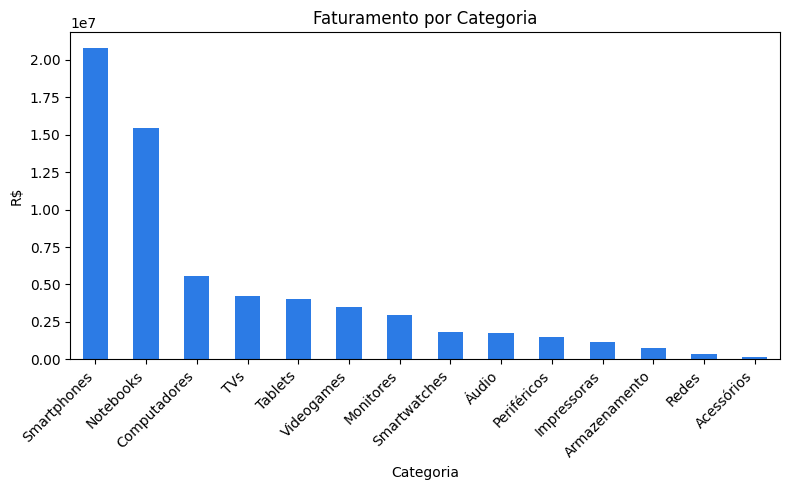

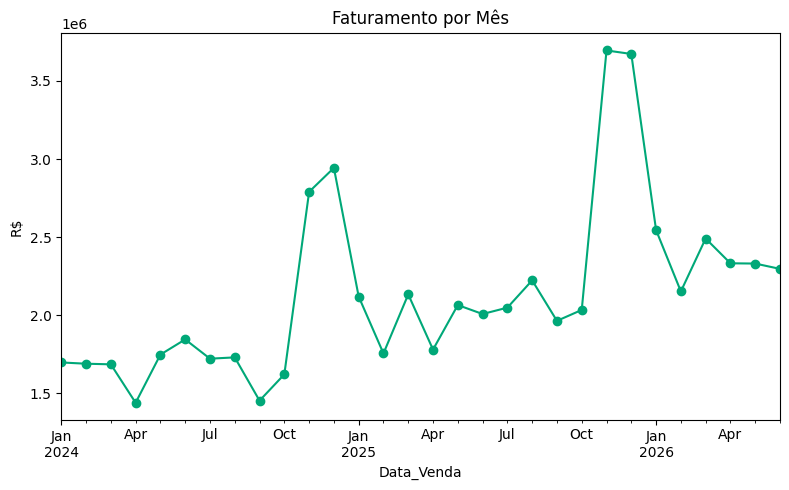

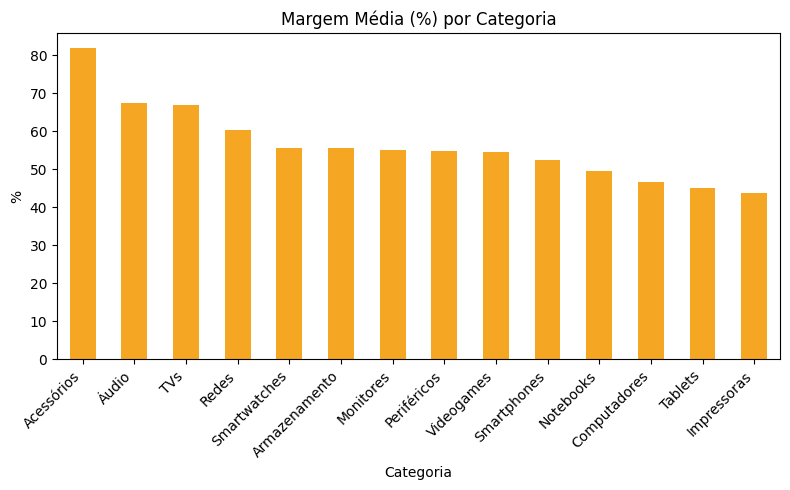

In [ ]:
# ==========================================
# --- CÉLULA 7: GRÁFICOS ---
# ==========================================

# 1. Faturamento por categoria
if "Categoria" in base_df.columns:
    fat_categoria = base_df.groupby("Categoria")["Faturamento"].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    fat_categoria.plot(kind="bar", color="#2c7be5")
    plt.title("Faturamento por Categoria")
    plt.ylabel("R$")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 2. Faturamento ao longo do tempo (se tiver coluna de data)
col_data = next((c for c in base_df.columns if "Data" in c), None)
if col_data:
    base_df[col_data] = pd.to_datetime(base_df[col_data], errors="coerce", dayfirst=True)
    fat_tempo = base_df.groupby(base_df[col_data].dt.to_period("M"))["Faturamento"].sum()
    plt.figure(figsize=(8, 5))
    fat_tempo.plot(kind="line", marker="o", color="#00a878")
    plt.title("Faturamento por Mês")
    plt.ylabel("R$")
    plt.tight_layout()
    plt.show()

# 3. Margem média por categoria
if "Categoria" in base_df.columns and "Margem_Calculada_Pct" in base_df.columns:
    margem_categoria = base_df.groupby("Categoria")["Margem_Calculada_Pct"].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    margem_categoria.plot(kind="bar", color="#f5a623")
    plt.title("Margem Média (%) por Categoria")
    plt.ylabel("%")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
# ==========================================
# --- CÉLULA 8: EXPORTAR PARA O LOOKER STUDIO ---
# ==========================================
# O Looker Studio não lê arquivos direto do seu computador: ele conecta em uma
# fonte "viva" -- normalmente Google Sheets, BigQuery ou um CSV no Google Drive.
# O caminho mais simples pra você agora é: salvar aqui no Drive -> no Looker Studio,
# escolher fonte de dados "Arquivo do Google Drive" -> apontar pra esse CSV.

base_df.to_csv(SAIDA_CSV, index=False, encoding="utf-8-sig")
print(f"Base exportada para: {SAIDA_CSV}")
print(f"Colunas ({len(base_df.columns)}): {list(base_df.columns)}")

Base exportada para: /content/drive/MyDrive/Emerson/emerson/base_dashboard.csv
Colunas (74): ['Item_ID', 'Pedido_ID', 'Data_Venda', 'Hora_Venda', 'Ano', 'Mes_Numero', 'Mes', 'Ano_Mes', 'Trimestre', 'Semestre', 'Dia_Semana', 'Final_de_Semana', 'Cliente_ID', 'Nome_Cliente', 'Sexo', 'Idade', 'Faixa_Etaria', 'Cidade', 'Estado', 'Regiao', 'Profissao', 'Faixa_Renda', 'Cliente_VIP', 'Produto_ID', 'SKU', 'Categoria', 'Marca_x', 'Produto', 'Quantidade', 'Preco_Unitario', 'Valor_Bruto', 'Desconto_Pct', 'Valor_Desconto', 'Valor_Mercadorias', 'Frete_Cobrado', 'Frete_Gratis', 'Custo_Logistico', 'Marketplace', 'Canal_Venda', 'Origem_Trafego', 'Campanha', 'Forma_Pagamento', 'Parcelas', 'Taxa_Financeira', 'Comissao_Pct', 'Comissao_Valor', 'Custo_Produto', 'Impostos', 'Custo_Marketing', 'Receita_Liquida', 'Lucro', 'Margem_Pct', 'Margem_Contribuicao', 'Status_Pedido', 'Transportadora', 'Data_Envio', 'Data_Entrega', 'Prazo_Prometido_Dias', 'Atraso_Dias', 'Entrega_no_Prazo', 'Devolucao', 'Motivo_Devolucao

In [ ]:
import os

os.path.exists(SAIDA_CSV)

True